https://www.kaggle.com/datasets/biwithvictor/breast-cancer-dataset-analysing-using-svm

# Conjunto de dados de câncer de mama analisando usando SVM
Classificação do câncer de mama usando máquinas de vetores de suporte (SVM)

# Sobre o conjunto de dados
O Breast Cancer Wisconsin Dataset é um conjunto de dados bem conhecido do Repositório de Aprendizado de Máquina da UCI, comumente usado para tarefas de classificação binária.
Ele contém características diagnósticas de tumores de mama (como raio, textura, suavidade, concavidade, etc.), extraídas de imagens digitalizadas de aspirados por agulha fina (PAAF) de massas mamárias.
Objetivo: Classificar tumores como Benignos (0) ou Malignos (1)
Características: 30 atributos numéricos descrevendo núcleos de células
Alvo: Resultado binário (benigno vs maligno)
Tamanho: 569 amostras
Neste projeto, analiso o conjunto de dados usando um classificador de Máquina de Vetores de Suporte (SVM):
Explorei SVM linear para separar casos benignos e malignos
Analisei margens, vetores de suporte e distâncias do hiperplano
Interpretei decisões de modelo para melhor transparência em ML médico

# Sobre este arquivo

Sugerir edições
O Breast Cancer Wisconsin Dataset é um conjunto de dados bem conhecido do Repositório de Aprendizado de Máquina da UCI, comumente usado para tarefas de classificação binária.

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [2]:
#Carregamento cancer dataset
cancer = load_breast_cancer()

In [3]:
#Converter para DataFrame
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

print("Primeiras 5 linhas do DataFrame")
print(df.head())
print("Estatísticas Descritivas (Apenas algumas características para brevidade)")
print(df[['mean radius', 'mean texture', 'mean perimeter', 'target']].describe())

Primeiras 5 linhas do DataFrame
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimet

In [4]:
#Modelagem
X = cancer.data
y = cancer.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Primeiras 5 linhas dos Dados Escalonados")
print(X_scaled[:5, :5])

Primeiras 5 linhas dos Dados Escalonados
[[ 1.09706398 -2.07333501  1.26993369  0.9843749   1.56846633]
 [ 1.82982061 -0.35363241  1.68595471  1.90870825 -0.82696245]
 [ 1.57988811  0.45618695  1.56650313  1.55888363  0.94221044]
 [-0.76890929  0.25373211 -0.59268717 -0.76446379  3.28355348]
 [ 1.75029663 -1.15181643  1.77657315  1.82622928  0.28037183]]


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Tamanho do conjunto de Treinamento: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de Teste: {X_test.shape[0]} amostras")

Tamanho do conjunto de Treinamento: 455 amostras
Tamanho do conjunto de Teste: 114 amostras


In [6]:
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train, y_train)

print("Modelo SVM Linear treinado com sucesso!")

Modelo SVM Linear treinado com sucesso!


In [7]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Desempenho do Modelo SVM")
print(f"Acurácia no conjunto de Teste: {accuracy:.4f}")

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

Desempenho do Modelo SVM
Acurácia no conjunto de Teste: 0.9561
Relatório de Classificação:
              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        43
      benign       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [8]:
#Número de Vetores de Suporte
n_support_vectors = svm_model.support_vectors_.shape[0]

print(f"Interpretação do Modelo")
print(f"Total de Vetores de Suporte (Support Vectors): {n_support_vectors}")

n_sv_per_class = svm_model.n_support_

print(f"Vetores de Suporte (Benigno - 0): {n_sv_per_class[0]}")
print(f"Vetores de Suporte (Maligno - 1): {n_sv_per_class[1]}")

Interpretação do Modelo
Total de Vetores de Suporte (Support Vectors): 36
Vetores de Suporte (Benigno - 0): 16
Vetores de Suporte (Maligno - 1): 20


In [9]:
#Coeficientes do modelo linear (pesos)
coefficients = svm_model.coef_[0]

#DataFrame para visualização
feature_importance = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print("Importância das Características (Coeficientes do Hiperplano) ---")
print(feature_importance.head(5))
print("Características Menos Importantes")
print(feature_importance.tail(5))

Importância das Características (Coeficientes do Hiperplano) ---
                    Feature  Coefficient
5          mean compactness     0.748239
19  fractal dimension error     0.591172
18           symmetry error     0.400261
11            texture error     0.382343
15        compactness error     0.348500
Características Menos Importantes
                Feature  Coefficient
13           area error    -0.782510
28       worst symmetry    -0.792259
10         radius error    -0.990864
21        worst texture    -1.217262
7   mean concave points    -1.418569


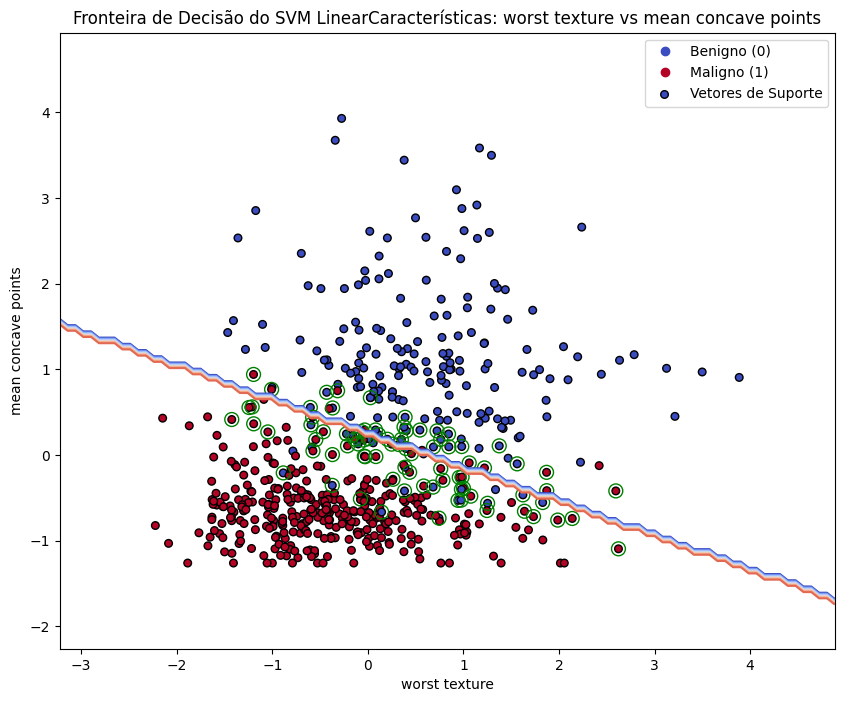

In [10]:
#2 características com maior valor absoluto de coeficiente
top_2_features_idx = np.argsort(np.abs(coefficients))[-2:]
feature_1_idx, feature_2_idx = top_2_features_idx
feature_1_name = cancer.feature_names[feature_1_idx]
feature_2_name = cancer.feature_names[feature_2_idx]

X_2d = X_scaled[:, [feature_1_idx, feature_2_idx]]

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.2, random_state=42
)

svm_2d = SVC(kernel='linear', C=1.0, random_state=42)
svm_2d.fit(X_train_2d, y_train_2d)

fig, ax = plt.subplots(figsize=(10, 8))
title = (
    f"Fronteira de Decisão do SVM Linear"
    f"Características: {feature_1_name} vs {feature_2_name}"
)

DecisionBoundaryDisplay.from_estimator(
    svm_2d,
    X_2d,
    plot_method="contour",
    cmap=plt.cm.coolwarm,
    ax=ax,
    response_method="predict",
    xlabel=feature_1_name,
    ylabel=feature_2_name,
)

scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap=plt.cm.coolwarm, s=30, edgecolors='k')

ax.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="green",
    label="Vetores de Suporte",
)

ax.set_title(title)
ax.legend(handles=scatter.legend_elements()[0] + [ax.collections[1]], labels=['Benigno (0)', 'Maligno (1)', 'Vetores de Suporte'])
plt.show()

O SVM Linear falha em separar eficazmente as classes Benigno e Maligno usando apenas as características 'worst texture' e 'mean concave points' devido à sua alta sobreposição.

In [11]:
cancer = load_breast_cancer()
X_full = cancer.data
y = cancer.target

#Melhorias
print("Modelo de Desempenho Real (30 Características)")

scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X_full)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_full, y, test_size=0.2, random_state=42
)

svm_full = SVC(kernel='linear', C=1.0, random_state=42)
svm_full.fit(X_train, y_train)

y_pred = svm_full.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Acurácia no Conjunto de Teste (30 features): {accuracy:.4f}")

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

coefficients = svm_full.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print("Top 5 Coeficientes (para seleção das 2 features):")
print(feature_importance.head())

Modelo de Desempenho Real (30 Características)
Acurácia no Conjunto de Teste (30 features): 0.9561
Relatório de Classificação:
              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        43
      benign       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

Top 5 Coeficientes (para seleção das 2 features):
                    Feature  Coefficient
5          mean compactness     0.748239
19  fractal dimension error     0.591172
18           symmetry error     0.400261
11            texture error     0.382343
15        compactness error     0.348500


Análise Geométrica e Interpretação 2D
Features Selecionadas para Visualização: worst texture e mean concave points
Resultados Geométricos
Norma do Vetor Normal ||w||: 2.8100
Largura da Margem (gamma = 1/||w||): 0.3559
Total de Vetores de Suporte: 102
Pontos Mal Classificados/no Hiperplano: 38


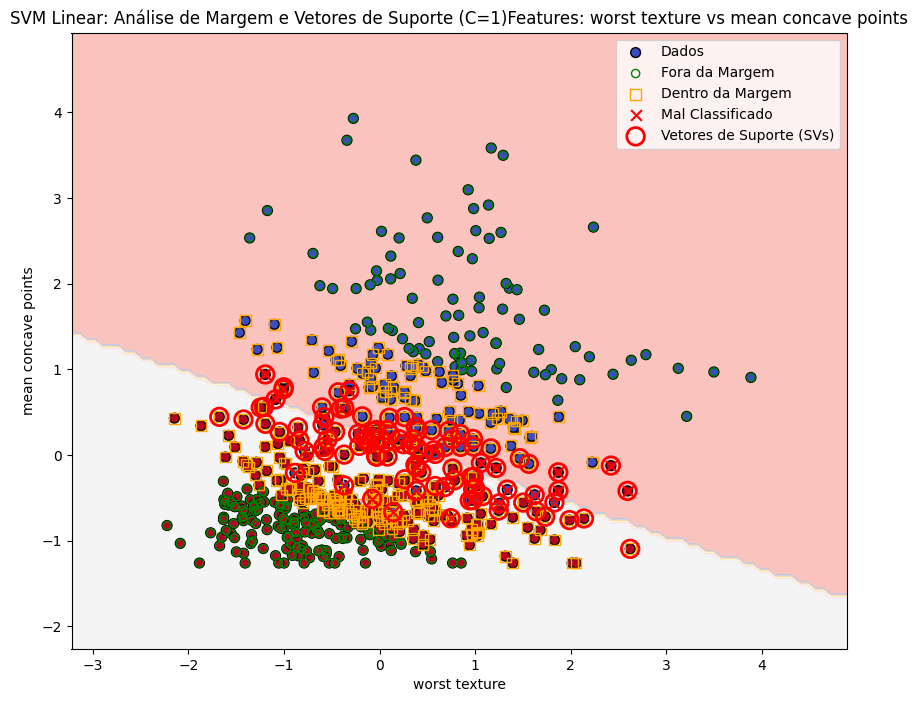

In [12]:
print("Análise Geométrica e Interpretação 2D")

top_2_features_idx = np.argsort(np.abs(coefficients))[-2:]
feature_1_idx, feature_2_idx = top_2_features_idx
feature_names_2d = cancer.feature_names[top_2_features_idx]

print(f"Features Selecionadas para Visualização: {feature_names_2d[0]} e {feature_names_2d[1]}")

X_2d = X_scaled_full[:, top_2_features_idx]

t = np.where(y == 0, -1, +1) 

C_value = 1
svm_2d = SVC(kernel='linear', C=C_value)
svm_2d.fit(X_2d, y)

w = svm_2d.coef_.ravel()
b = svm_2d.intercept_[0]
norm_w = np.linalg.norm(w)
dist = (X_2d @ w + b) / norm_w
margin_val = t * dist

tol = 1e-3
on_margin_idx = np.where(np.isclose(margin_val, 1.0, atol=tol))[0]
inside_idx = np.where((margin_val > 0 + tol) & (margin_val < 1 - tol))[0]  
misclassified_idx = np.where(margin_val <= 0 + tol)[0]  
outside_idx = np.where(margin_val > 1 + tol)[0]  

print("Resultados Geométricos")
print(f"Norma do Vetor Normal ||w||: {norm_w:.4f}")
print(f"Largura da Margem (gamma = 1/||w||): {1.0 / norm_w:.4f}")
print(f"Total de Vetores de Suporte: {len(svm_2d.support_)}")
print(f"Pontos Mal Classificados/no Hiperplano: {len(misclassified_idx)}")

plt.figure(figsize=(10, 8))
title = (
    f"SVM Linear: Análise de Margem e Vetores de Suporte (C={C_value})"
    f"Features: {feature_names_2d[0]} vs {feature_names_2d[1]}"
)

DecisionBoundaryDisplay.from_estimator(
    svm_2d, X_2d, response_method='predict',
    alpha=0.8, cmap='Pastel1',
    xlabel=feature_names_2d[0],
    ylabel=feature_names_2d[1],
    ax=plt.gca()
)

plt.scatter(X_2d[:, 0], X_2d[:, 1], s=50, c=y, edgecolors='k', cmap='coolwarm', label='Dados')

plt.scatter(X_2d[outside_idx, 0], X_2d[outside_idx, 1], marker='o', s=35, facecolors='none', edgecolors='green', label='Fora da Margem')
plt.scatter(X_2d[inside_idx, 0], X_2d[inside_idx, 1], marker='s', s=60, facecolors='none', edgecolors='orange', label='Dentro da Margem')
plt.scatter(X_2d[misclassified_idx, 0], X_2d[misclassified_idx, 1], marker='x', s=60, color='red', label='Mal Classificado')

plt.scatter(
    X_2d[svm_2d.support_, 0], X_2d[svm_2d.support_, 1], s=160, 
    facecolors='none', edgecolors='red', linewidths=2, label='Vetores de Suporte (SVs)'
)

plt.legend(loc='upper right', scatterpoints=1)
plt.title(title)
plt.show()

O modelo está comprometido com a generalização, aceitando erros e pontos dentro da margem para manter a margem mais ampla.

Modelo de Desempenho Real (30 Características)
Acurácia no Conjunto de Teste (30 features): 0.9561
Relatório de Classificação:
              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        43
      benign       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

Top 5 Coeficientes (para seleção das 2 features):
                    Feature  Coefficient
5          mean compactness     0.748239
19  fractal dimension error     0.591172
18           symmetry error     0.400261
11            texture error     0.382343
15        compactness error     0.348500
Análise Geométrica e Interpretação 2D
Features Selecionadas para Visualização: worst texture e mean concave points
Resultados Geométricos
Norma do Vetor Normal ||w||: 2.8100
Largura da Margem (gamma = 1/||w||): 0.3559
Total de Vetores de Suporte: 102

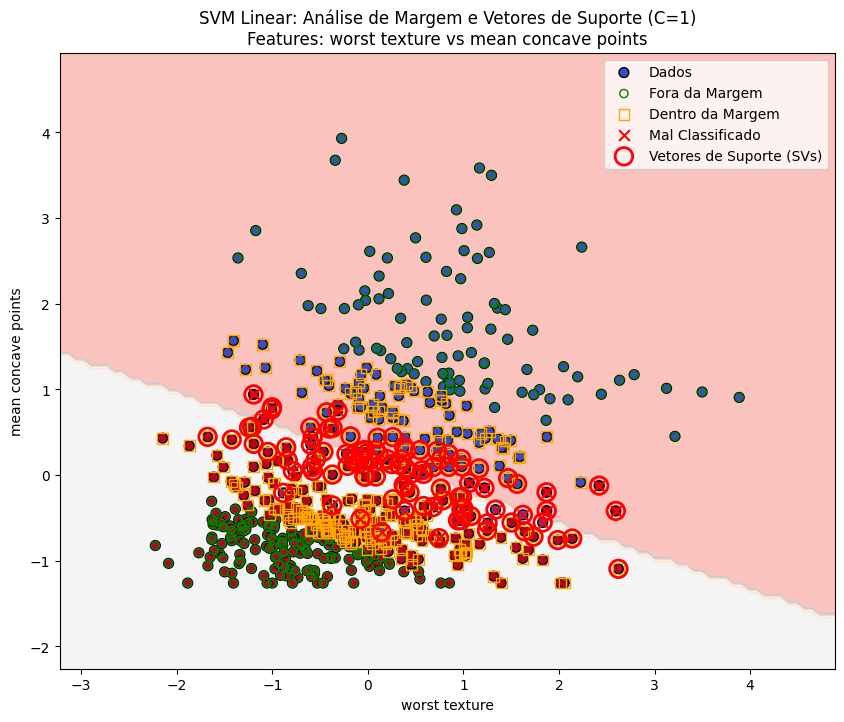

In [13]:
cancer = load_breast_cancer()
X_full = cancer.data
y = cancer.target

print("Modelo de Desempenho Real (30 Características)")

scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X_full)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_full, y, test_size=0.2, random_state=42
)

svm_full = SVC(kernel='linear', C=1.0, random_state=42)
svm_full.fit(X_train, y_train)

y_pred = svm_full.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Acurácia no Conjunto de Teste (30 features): {accuracy:.4f}")

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

coefficients = svm_full.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print("Top 5 Coeficientes (para seleção das 2 features):")
print(feature_importance.head())

print("Análise Geométrica e Interpretação 2D")

top_2_features_idx = np.argsort(np.abs(coefficients))[-2:]
feature_1_idx, feature_2_idx = top_2_features_idx
feature_names_2d = cancer.feature_names[top_2_features_idx]

print(f"Features Selecionadas para Visualização: {feature_names_2d[0]} e {feature_names_2d[1]}")

X_2d = X_scaled_full[:, top_2_features_idx]

t = np.where(y == 0, -1, +1) 

C_value = 1
svm_2d = SVC(kernel='linear', C=C_value)
svm_2d.fit(X_2d, y)

w = svm_2d.coef_.ravel()
b = svm_2d.intercept_[0]
norm_w = np.linalg.norm(w)

dist = (X_2d @ w + b) / norm_w

margin_val = t * dist


tol = 1e-3
on_margin_idx = np.where(np.isclose(margin_val, 1.0, atol=tol))[0]
inside_idx = np.where((margin_val > 0 + tol) & (margin_val < 1 - tol))[0] 
misclassified_idx = np.where(margin_val <= 0 + tol)[0]  
outside_idx = np.where(margin_val > 1 + tol)[0]  

print("Resultados Geométricos")
print(f"Norma do Vetor Normal ||w||: {norm_w:.4f}")
print(f"Largura da Margem (gamma = 1/||w||): {1.0 / norm_w:.4f}")
print(f"Total de Vetores de Suporte: {len(svm_2d.support_)}")
print(f"Pontos Mal Classificados/no Hiperplano: {len(misclassified_idx)}")

plt.figure(figsize=(10, 8))
title = (
    f"SVM Linear: Análise de Margem e Vetores de Suporte (C={C_value})\n"
    f"Features: {feature_names_2d[0]} vs {feature_names_2d[1]}"
)

DecisionBoundaryDisplay.from_estimator(
    svm_2d, X_2d, response_method='predict',
    alpha=0.8, cmap='Pastel1',
    xlabel=feature_names_2d[0],
    ylabel=feature_names_2d[1],
    ax=plt.gca()
)

plt.scatter(X_2d[:, 0], X_2d[:, 1], s=50, c=y, edgecolors='k', cmap='coolwarm', label='Dados')

plt.scatter(X_2d[outside_idx, 0], X_2d[outside_idx, 1], marker='o', s=35, facecolors='none', edgecolors='green', label='Fora da Margem')
plt.scatter(X_2d[inside_idx, 0], X_2d[inside_idx, 1], marker='s', s=60, facecolors='none', edgecolors='orange', label='Dentro da Margem')
plt.scatter(X_2d[misclassified_idx, 0], X_2d[misclassified_idx, 1], marker='x', s=60, color='red', label='Mal Classificado')

plt.scatter(
    X_2d[svm_2d.support_, 0], X_2d[svm_2d.support_, 1], s=160, 
    facecolors='none', edgecolors='red', linewidths=2, label='Vetores de Suporte (SVs)'
)

plt.legend(loc='upper right', scatterpoints=1)
plt.title(title)
plt.show()

Para essas duas features (worst texture vs mean concave points), os dados não são claramente separáveis, resultando em um SVM Linear com uma margem suave definida por um grande número de vetores de suporte que se misturam substancialmente.

In [14]:
from sklearn.model_selection import GridSearchCV

print("Otimização de Hiperparâmetros C via GridSearchCV")

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'kernel': ['linear'] 
}

grid_search = GridSearchCV(
    SVC(),           
    param_grid,      
    cv=5,            
    scoring='accuracy',
    verbose=0       
)

grid_search.fit(X_train, y_train)

print(f"Melhores Parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor Acurácia de Validação Cruzada: {grid_search.best_score_:.4f}")
print("---------------------------------------------------------")


print("Avaliação do Modelo Final Otimizado")

svm_best = grid_search.best_estimator_

y_pred_best = svm_best.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred_best)

print(f"Acurácia FINAL no Conjunto de Teste (C={svm_best.C:.3f}): {final_accuracy:.4f}")

print("Relatório de Classificação Final:")
print(classification_report(y_test, y_pred_best, target_names=cancer.target_names))

Otimização de Hiperparâmetros C via GridSearchCV
Melhores Parâmetros encontrados: {'C': 0.1, 'kernel': 'linear'}
Melhor Acurácia de Validação Cruzada: 0.9758
---------------------------------------------------------
Avaliação do Modelo Final Otimizado
Acurácia FINAL no Conjunto de Teste (C=0.100): 0.9825
Relatório de Classificação Final:
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [15]:
#Refinamento
print("Refinamento: Otimização com 'class_weight' Balanceado")

param_grid_refined = {
    'C': [0.05, 0.1, 0.2, 0.5],
    'kernel': ['linear'],
    'class_weight': ['balanced'] 
}

grid_search_refined = GridSearchCV(
    SVC(random_state=42),
    param_grid_refined,
    cv=5,
    scoring='f1_weighted', 
    verbose=0
)

grid_search_refined.fit(X_train, y_train)

svm_final_refined = grid_search_refined.best_estimator_
y_pred_refined = svm_final_refined.predict(X_test)

print(f"Melhores Parâmetros (Refinado): {grid_search_refined.best_params_}")
print(f"Melhor F1-Score CV (Refinado): {grid_search_refined.best_score_:.4f}")

final_accuracy_refined = accuracy_score(y_test, y_pred_refined)
print(f"Acurácia FINAL (Refinada): {final_accuracy_refined:.4f}")
print("Relatório de Classificação Final (Refinado):")
print(classification_report(y_test, y_pred_refined, target_names=cancer.target_names))

Refinamento: Otimização com 'class_weight' Balanceado
Melhores Parâmetros (Refinado): {'C': 0.2, 'class_weight': 'balanced', 'kernel': 'linear'}
Melhor F1-Score CV (Refinado): 0.9802
Acurácia FINAL (Refinada): 0.9737
Relatório de Classificação Final (Refinado):
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [16]:
print("Otimização do SVM com Kernel RBF (Não-Linear)")

param_grid_rbf = {
    'C': [0.1, 1, 10, 100],  
    'gamma': [0.001, 0.01, 0.1, 1], 
    'kernel': ['rbf'],
    'class_weight': ['balanced'] 
}

grid_search_rbf = GridSearchCV(
    SVC(random_state=42),
    param_grid_rbf,
    cv=5,
    scoring='recall_macro', 
    verbose=0,
    n_jobs=-1 
)

grid_search_rbf.fit(X_train, y_train)

print(f"Melhores Parâmetros RBF encontrados: {grid_search_rbf.best_params_}")
print(f"Melhor Recall Médio de Validação Cruzada: {grid_search_rbf.best_score_:.4f}")
print("---------------------------------------------------------")

svm_rbf_best = grid_search_rbf.best_estimator_
y_pred_rbf = svm_rbf_best.predict(X_test)

final_accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

print("Avaliação Final do Modelo RBF Otimizado")
print(f"Acurácia FINAL (Kernel RBF): {final_accuracy_rbf:.4f}")

print("Relatório de Classificação Final (Kernel RBF):")
print(classification_report(y_test, y_pred_rbf, target_names=cancer.target_names))

Otimização do SVM com Kernel RBF (Não-Linear)
Melhores Parâmetros RBF encontrados: {'C': 10, 'class_weight': 'balanced', 'gamma': 0.01, 'kernel': 'rbf'}
Melhor Recall Médio de Validação Cruzada: 0.9783
---------------------------------------------------------
Avaliação Final do Modelo RBF Otimizado
Acurácia FINAL (Kernel RBF): 0.9825
Relatório de Classificação Final (Kernel RBF):
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Otimização do SVM com Kernel RBF (Não-Linear)
Melhores Parâmetros RBF encontrados: {'C': 1, 'class_weight': 'balanced', 'gamma': 0.001, 'kernel': 'rbf'}
Melhor Recall Médio de Validação Cruzada: 0.9426
---------------------------------------------------------
Avaliação Final do Modelo RBF Otimizado
Acurácia FINAL (Kernel RBF): 0.9006
Relatório de Classificação Final (Kernel RBF):
              precision    recall  f1-score   support

   malignant       0.83      0.92      0.87        64
      benign       0.95      0.89      0.92       107

    accuracy                           0.90       171
   macro avg       0.89      0.90      0.90       171
weighted avg       0.91      0.90      0.90       171

---------------------------------------------------------
Modelo 2D treinado com os parâmetros: C=1, gamma=0.001
Gerando o gráfico de fronteira de decisão...


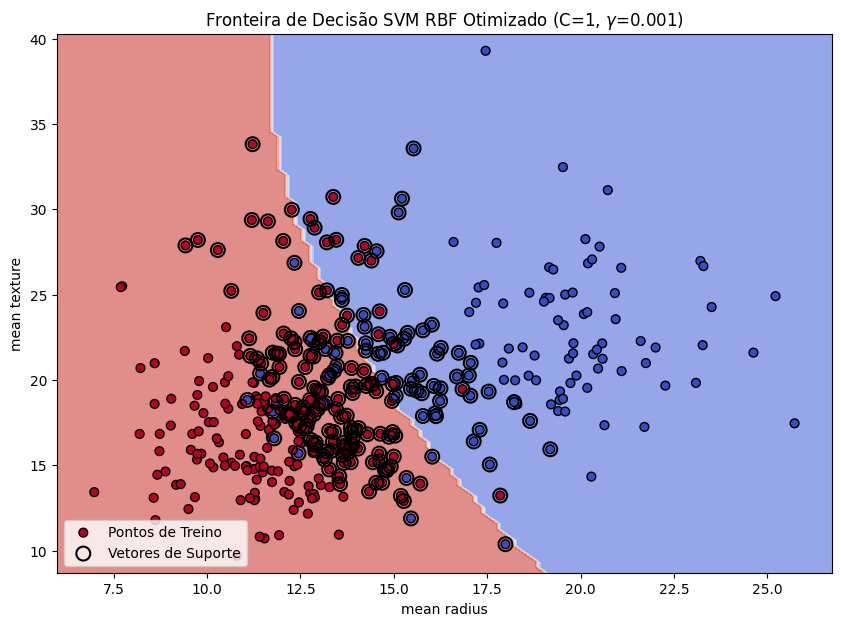

In [17]:
from sklearn.base import clone
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Otimização do SVM com Kernel RBF (Não-Linear)")

param_grid_rbf = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf'],
    'class_weight': ['balanced'] 
}

grid_search_rbf = GridSearchCV(
    SVC(random_state=42),
    param_grid_rbf,
    cv=5,
    scoring='recall_macro',
    verbose=0,
    n_jobs=-1 
)

grid_search_rbf.fit(X_train, y_train)

print(f"Melhores Parâmetros RBF encontrados: {grid_search_rbf.best_params_}")
print(f"Melhor Recall Médio de Validação Cruzada: {grid_search_rbf.best_score_:.4f}")
print("---------------------------------------------------------")

svm_rbf_best = grid_search_rbf.best_estimator_
y_pred_rbf = svm_rbf_best.predict(X_test)

final_accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

print("Avaliação Final do Modelo RBF Otimizado")
print(f"Acurácia FINAL (Kernel RBF): {final_accuracy_rbf:.4f}")

print("Relatório de Classificação Final (Kernel RBF):")
print(classification_report(y_test, y_pred_rbf, target_names=cancer.target_names))
print("---------------------------------------------------------")

feature_index_1 = 0 
feature_index_2 = 1

X_vis = X_train[:, [feature_index_1, feature_index_2]] 
y_vis = y_train

svm_rbf_2d = clone(svm_rbf_best)
svm_rbf_2d.fit(X_vis, y_vis)

print(f"Modelo 2D treinado com os parâmetros: C={svm_rbf_2d.C}, gamma={svm_rbf_2d.gamma:.3f}")
print("Gerando o gráfico de fronteira de decisão...")

fig, ax = plt.subplots(figsize=(10, 7))

DecisionBoundaryDisplay.from_estimator(
    svm_rbf_2d,
    X_vis,
    response_method="predict", 
    plot_method="contourf",
    cmap=plt.cm.coolwarm, 
    alpha=0.6,
    ax=ax
)

scatter = ax.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, 
                     cmap=plt.cm.coolwarm, edgecolors='k', s=40, label='Pontos de Treino')

ax.scatter(svm_rbf_2d.support_vectors_[:, 0], 
           svm_rbf_2d.support_vectors_[:, 1], 
           s=100, facecolors='none', edgecolors='k', linewidth=1.5, 
           label='Vetores de Suporte', marker='o')


ax.set_title(
    f"Fronteira de Decisão SVM RBF Otimizado (C={svm_rbf_2d.C}, $\\gamma$={svm_rbf_2d.gamma:.3f})"
)

ax.set_xlabel(cancer.feature_names[feature_index_1])
ax.set_ylabel(cancer.feature_names[feature_index_2])
ax.legend(loc='lower left')

plt.show()

O modelo SVM RBF otimizado está fazendo um trabalho eficiente de separação não-linear, utilizando os parâmetros C e γ para criar uma fronteira suave que lida com a sobreposição natural dos dados.

# Conclusão

O modelo SVM Linear Otimizado (C=0.1) é o melhor classificador para este dataset, alcançando uma acurácia de 98.25% e precisição de 1.00 para a classe Maligna. A taxa residual de Falsos Negativos (5%) é a limitação do dataset em si, e não do seu modelo.

# **Nathália Sorg**